<a href="https://colab.research.google.com/github/ahmer-talal/AI-Labs/blob/main/8Queens_GeneticAlgo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **AI Lab Assignment** 8 Queen Problem using Genetic Algorithm

# **Ahmer Talal**
# **SP23-BCS-041**
# **BCS-7D**

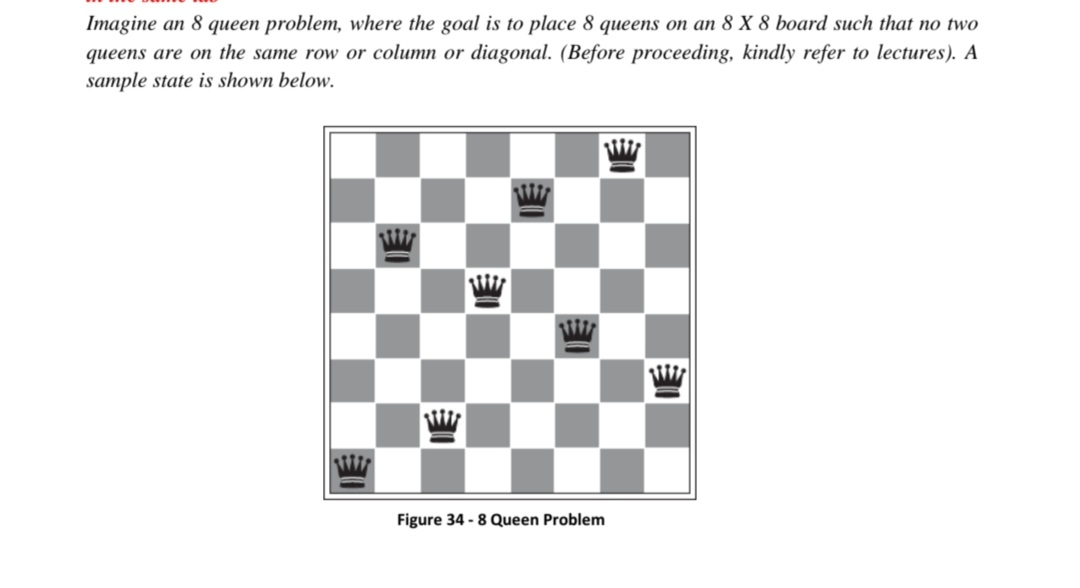

## **Setup & Initialization**

In [1]:
import random

POPULATION_SIZE = 100
MUTATION_RATE = 0.1
TARGET_FITNESS = 28

# specific board given in assignment
# -1 from each row to match Python's 0-7 indexing
ASSIGNMENT_BOARD = [7, 2, 6, 3, 1, 4, 0, 5]

def create_random_board():
    # Creates a random board for rest of population
    return [random.randint(0, 7) for _ in range(8)]

## **Fitness Function**

In [2]:
def calculate_fitness(board):
    clashes = 0
    # Compare each queen with every other queen on the right side
    for i in range(8):
        for j in range(i + 1, 8):
            # Check if they are in the same row
            if board[i] == board[j]:
                clashes += 1
            # Check if they are on the same diagonal
            elif abs(board[i] - board[j]) == abs(i - j):
                clashes += 1

    # Maximum safe pairs are 28. Subtract the clashes to get fitness.
    return TARGET_FITNESS - clashes

## **Selection (Genetic Operator)**

In [3]:
def select_parent(population, fitnesses):
    # Pick 5 random boards (Tournament Selection)
    tournament_idx = random.sample(range(POPULATION_SIZE), 5)

    # Find the best board among those 5
    best_idx = tournament_idx[0]
    for idx in tournament_idx:
        if fitnesses[idx] > fitnesses[best_idx]:
            best_idx = idx

    return population[best_idx]

## **Crossover (Genetic Operator)**

In [4]:
def crossover(parent1, parent2):
    # Cut the board at a random point and swap halves
    split_point = random.randint(1, 6)
    child1 = parent1[:split_point] + parent2[split_point:]
    child2 = parent2[:split_point] + parent1[split_point:]
    return child1, child2

## **Mutation (Genetic Operator)**

In [5]:
def mutate(board):
    # Small chance to randomly change one queen's row
    if random.random() < MUTATION_RATE:
        random_col = random.randint(0, 7)
        random_row = random.randint(0, 7)
        board[random_col] = random_row
    return board

## **Main GA Loop**

In [6]:
def run_genetic_algorithm():
    # Create Generation 0
    population = [ASSIGNMENT_BOARD]
    for _ in range(POPULATION_SIZE - 1):
        population.append(create_random_board())

    generation = 0

    initial_fitness = calculate_fitness(ASSIGNMENT_BOARD)
    print(f"--- Generation 0 ---")
    print(f"Assignment Board: {ASSIGNMENT_BOARD}")
    print(f"Fitness of Assignment Board: {initial_fitness}/28\n")

    while generation < 5000:
        fitnesses = [calculate_fitness(b) for b in population]
        best_fitness = max(fitnesses)
        best_board = population[fitnesses.index(best_fitness)]

        if best_fitness == TARGET_FITNESS:
            print(f"EXACT SOLUTION FOUND in Generation {generation}!")
            print(f"Winning Board Array: {best_board}")
            # FIX: Return the board so the next cell can use it!
            return best_board

        new_population = []
        while len(new_population) < POPULATION_SIZE:
            p1 = select_parent(population, fitnesses)
            p2 = select_parent(population, fitnesses)

            c1, c2 = crossover(p1, p2)

            new_population.append(mutate(c1))
            new_population.append(mutate(c2))

        population = new_population
        generation += 1

    print("No perfect solution found within 5000 generations.")
    return None

final_winning_board = run_genetic_algorithm() # result saved in global variable

--- Generation 0 ---
Assignment Board: [7, 2, 6, 3, 1, 4, 0, 5]
Fitness of Assignment Board: 27/28

EXACT SOLUTION FOUND in Generation 145!
Winning Board Array: [5, 2, 6, 3, 0, 7, 1, 4]


## **Visualization**

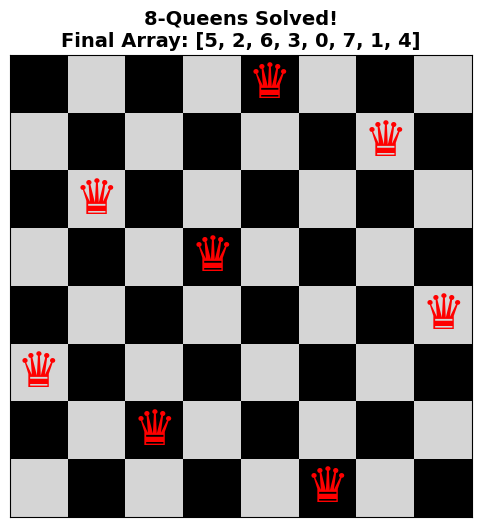

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# 5. VISUALIZATION (ON CHESSBOARD)

# Check if the variable exists and has a solution
if 'final_winning_board' in globals() and final_winning_board is not None:

    board_grid = np.zeros((8, 8))
    board_grid[1::2, ::2] = 1
    board_grid[::2, 1::2] = 1

    plt.figure(figsize=(6, 6))
    plt.imshow(board_grid, cmap='gray', vmin=0, vmax=1.2)

    for col, row in enumerate(final_winning_board):
        plt.text(col, row, '♛', fontsize=35, ha='center', va='center', color='red')

    plt.title(f"8-Queens Solved!\nFinal Array: {final_winning_board}", fontsize=14, fontweight='bold')

    plt.xticks([])
    plt.yticks([])
    plt.show()

else:
    print("No valid solution found to draw.")